<a href="https://colab.research.google.com/github/afrin2310/Ecommerce_Price_Analysis/blob/main/Ecommerce_Price_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                                   Title  Price  Rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5

Average Price: 34.560700000000004
Max Price: 58.11
Min Price: 10.16


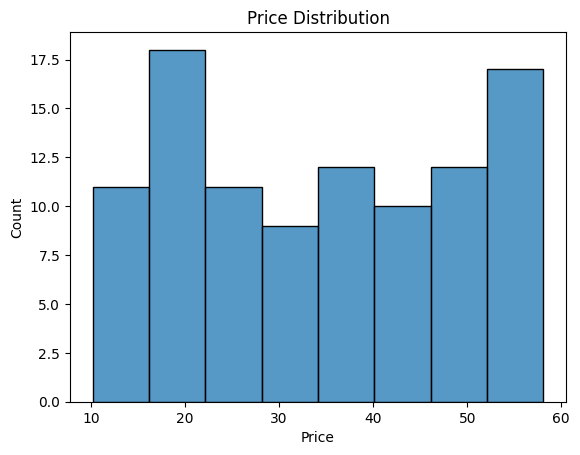

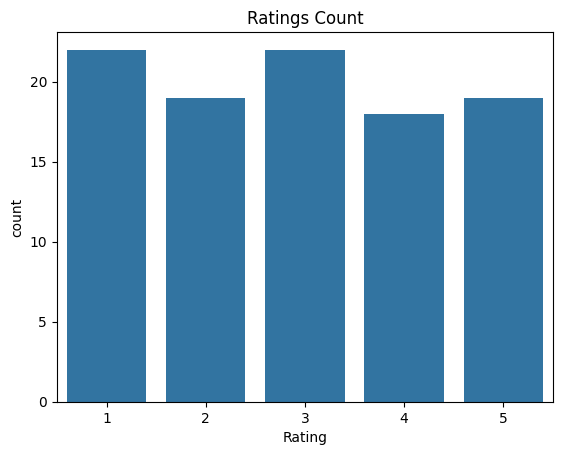

In [3]:
# Install libraries (only needed once)
!pip install -q requests beautifulsoup4 pandas matplotlib seaborn

# Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Base URL
base_url = "http://books.toscrape.com/catalogue/page-{}.html"

# Store data
all_data = []

# Loop through pages
for page in range(1, 6):
    url = base_url.format(page)

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print(f"Failed to retrieve page {page}")
        continue

    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.p["class"][1]

        all_data.append([title, price, rating])

# Create DataFrame
df = pd.DataFrame(all_data, columns=["Title", "Price", "Rating"])

# Clean Price
df["Price"] = df["Price"].str.replace("Â£", "", regex=False).astype(float)

# Convert Rating
rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
df["Rating"] = df["Rating"].map(rating_map)

# Show data
print(df.head())

# Save CSV
df.to_csv("books_data.csv", index=False)

# Basic Analysis
print("\nAverage Price:", df["Price"].mean())
print("Max Price:", df["Price"].max())
print("Min Price:", df["Price"].min())

# Visualization
plt.figure()
sns.histplot(df["Price"])
plt.title("Price Distribution")
plt.show()

plt.figure()
sns.countplot(x="Rating", data=df)
plt.title("Ratings Count")
plt.show()